https://www.kaggle.com/competitions/map-charting-student-math-misunderstandings/data

# MAP - Mapeando os mal-entendidos dos alunos sobre matemática
Prever a afinidade entre concepções errôneas e respostas abertas dos alunos

# Descrição do conjunto de dados
No Eedi, os alunos respondem a Perguntas Diagnósticas (DQs), que são questões de múltipla escolha com uma resposta correta e três incorretas, conhecidas como distrações. Após responder com uma opção de múltipla escolha, os alunos às vezes eram solicitados a fornecer uma explicação por escrito justificando a resposta selecionada. Essas explicações são o foco principal do conjunto de dados MAP e devem ser usadas para identificar e abordar potenciais equívocos no raciocínio dos alunos.

O objetivo da competição é desenvolver um modelo que execute 3 etapas:

Determina se a resposta selecionada está correta. (Verdadeiro ou Falso na categoria; por exemplo, Verdadeiro _Correto)
Avalia se a explicação contém um equívoco. (Correto, Equívoco ou Nenhum na categoria; por exemplo, Verdadeiro_Correto )
Identifica o equívoco específico presente, se houver.
As Perguntas de Diagnóstico foram apresentadas em formato de imagem na plataforma Eedi. Todo o conteúdo das perguntas, incluindo expressões matemáticas, foi extraído por meio de um processo de OCR com intervenção humana para garantir a precisão.

# Arquivos
[treinar/testar].csv

QuestionId- Identificador de pergunta exclusivo.
QuestionText- O texto da pergunta.
MC_Answer- A resposta de múltipla escolha que o aluno selecionou.
StudentExplanation- Uma explicação do aluno para a escolha de uma resposta específica de múltipla escolha.
Category- [somente treinamento] Uma classificação da relação entre a resposta de múltipla escolha de um aluno e sua explicação (por exemplo, Verdadeiro_Equívoco, que indica uma seleção correta de resposta de múltipla escolha acompanhada por uma explicação que revela um equívoco).
Misconception- [somente treinamento] O equívoco matemático identificado na explicação do aluno para as respostas. Aplicável somente quando a categoria contém um equívoco; caso contrário, é "NA".
sample_submission.csv - Um arquivo de envio no formato correto.

Category:Misconception- A Categoria de classificação prevista é concatenada com a Equívoco por dois pontos ( :). Podem ser feitas até três previsões, separadas por um espaço.
Os dados do teste de repetição contêm aproximadamente 16.000 linhas.

A competição MAP (Projeto de Anotação de Equívocos) desafia você a desenvolver um modelo de Processamento de Linguagem Natural (PLN) impulsionado por Aprendizado de Máquina (ML) que preveja possíveis equívocos matemáticos dos alunos com base em suas explicações. O objetivo é criar um modelo que identifique potenciais equívocos matemáticos que se generalizam para diferentes problemas.
Seu trabalho poderá ajudar a melhorar a compreensão e o gerenciamento de equívocos, aprimorando a experiência educacional tanto para alunos quanto para professores.

A Universidade Vanderbilt e a The Learning Agency fizeram uma parceria com a Kaggle para sediar esta competição.

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_df = pd.read_csv('sample_submission.csv')

In [223]:
train_df

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NaN
3,3,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NaN
4,4,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NaN
...,...,...,...,...,...,...,...
36691,36691,109465,The probability of an event occurring is \( 0....,Unlikely,very unlikely.,False_Neither,NaN
36692,36692,109465,The probability of an event occurring is \( 0....,Unlikely,yea pretty much unlikely from what it seems.,False_Neither,NaN
36693,36693,109465,The probability of an event occurring is \( 0....,Unlikely,yeah pretty unlikelyy from what it seems.,False_Neither,NaN
36694,36694,109465,The probability of an event occurring is \( 0....,Unlikely,you have 9 other numbers to get.,False_Neither,NaN


In [224]:
#Informações
train_df.info()
train_df.head()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36696 entries, 0 to 36695
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              36696 non-null  int64 
 1   QuestionId          36696 non-null  int64 
 2   QuestionText        36696 non-null  object
 3   MC_Answer           36696 non-null  object
 4   StudentExplanation  36696 non-null  object
 5   Category            36696 non-null  object
 6   Misconception       9860 non-null   object
dtypes: int64(2), object(5)
memory usage: 2.0+ MB


,row_id,QuestionId
count,36696.000000,36696.000000
mean,18347.500000,46356.825104
std,10593.367076,25617.723392
min,0.000000,31772.000000
25%,9173.750000,31777.000000
50%,18347.500000,32833.000000
75%,27521.250000,33474.000000
max,36695.000000,109465.000000


In [225]:
test_df

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation
0,36696,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"I think that 1/3 is the answer, as it's the si..."
1,36697,31772,What fraction of the shape is not shaded? Give...,\( \frac{3}{6} \),i think this answer is because 3 triangles are...
2,36698,32835,Which number is the greatest?,\( 6.2 \),because the 2 makes it higher than the others.


In [226]:
#Informações
test_df.info()
test_df.head()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              3 non-null      int64 
 1   QuestionId          3 non-null      int64 
 2   QuestionText        3 non-null      object
 3   MC_Answer           3 non-null      object
 4   StudentExplanation  3 non-null      object
dtypes: int64(2), object(3)
memory usage: 252.0+ bytes


,row_id,QuestionId
count,3.0,3.000000
mean,36697.0,32126.333333
std,1.0,613.723336
min,36696.0,31772.000000
25%,36696.5,31772.000000
50%,36697.0,31772.000000
75%,36697.5,32303.500000
max,36698.0,32835.000000


In [227]:
sample_df

,row_id,Category:Misconception
0,36696,True_Correct:NA False_Neither:NA False_Misconc...
1,36697,True_Correct:NA False_Neither:NA False_Misconc...
2,36698,True_Correct:NA False_Neither:NA False_Misconc...


In [228]:
sample_df.info()
sample_df.head()
sample_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   row_id                  3 non-null      int64 
 1   Category:Misconception  3 non-null      object
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


,row_id
count,3.0
mean,36697.0
std,1.0
min,36696.0
25%,36696.5
50%,36697.0
75%,36697.5
max,36698.0


In [229]:
category_counts = train_df['Category'].value_counts()
print("Distribuição da Coluna 'Category':")
print(category_counts)

Distribuição da Coluna 'Category':
Category
True_Correct           14802
False_Misconception     9457
False_Neither           6542
True_Neither            5265
True_Misconception       403
False_Correct            227
Name: count, dtype: int64


/tmp/ipython-input-374695027.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='mako')


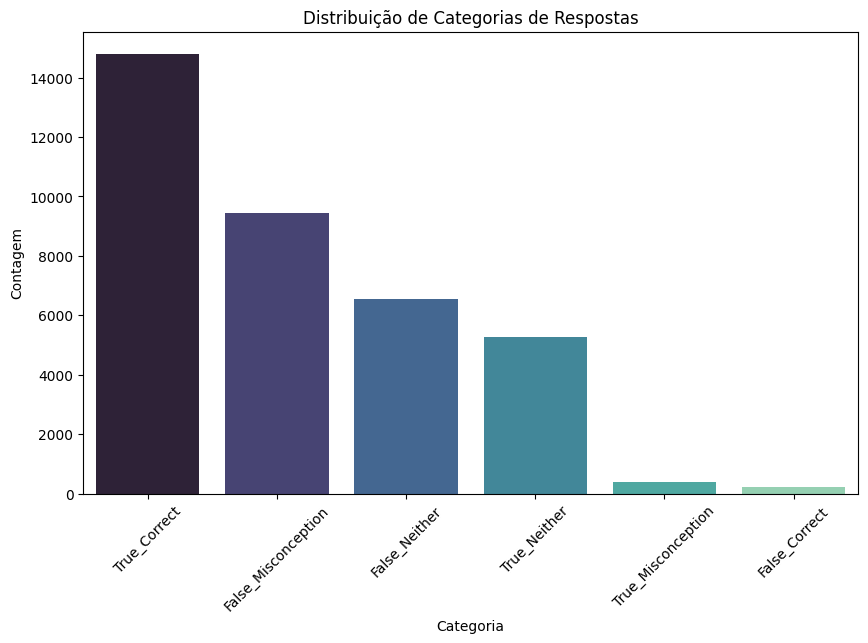

In [230]:
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='mako')
plt.title('Distribuição de Categorias de Respostas')
plt.xlabel('Categoria')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

In [231]:
misconception_counts = train_df['Misconception'].value_counts()
print("Distribuição da Coluna 'Misconception':")
print(misconception_counts.head(15))

Distribuição da Coluna 'Misconception':
Misconception
Incomplete                 1454
Additive                    929
Duplication                 704
Subtraction                 620
Positive                    566
Wrong_term                  558
Irrelevant                  497
Wrong_fraction              418
Inversion                   414
Mult                        353
Denominator-only_change     336
Whole_numbers_larger        329
Adding_across               307
WNB                         299
Tacking                     290
Name: count, dtype: int64


/tmp/ipython-input-590853469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=misconception_counts.head(15).index, y=misconception_counts.head(15).values, palette='magma')


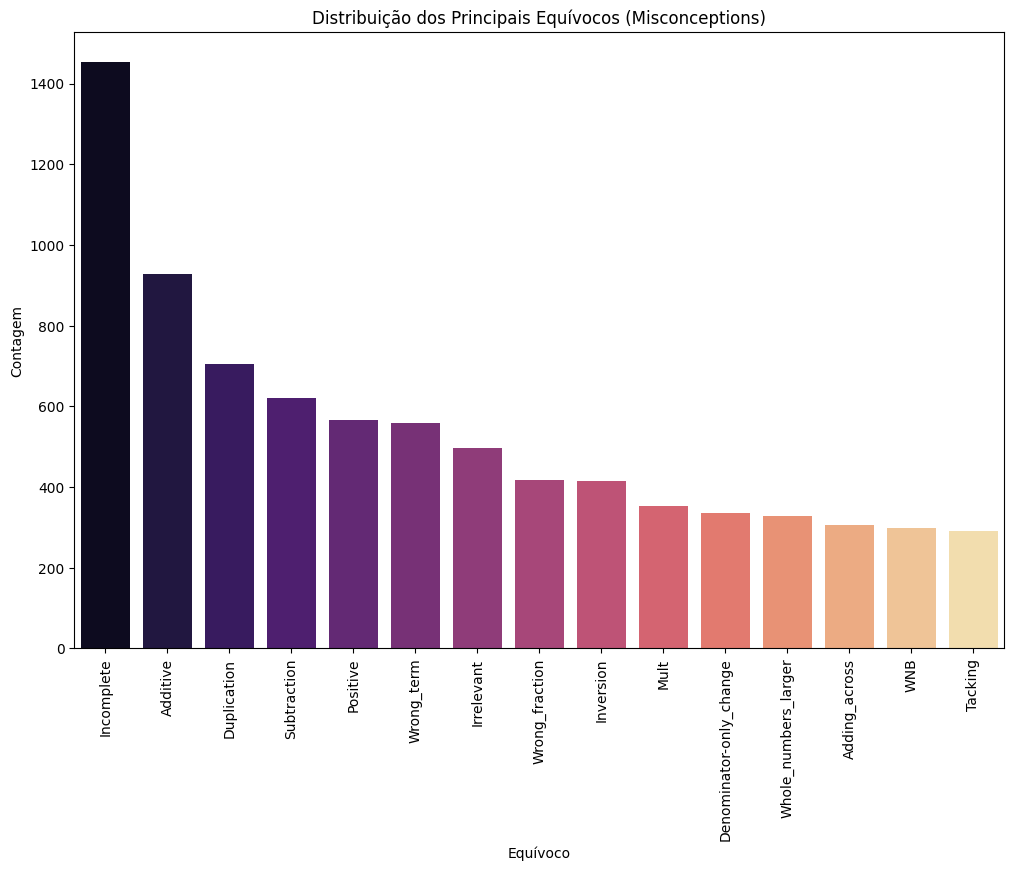

In [232]:
plt.figure(figsize=(12, 8))
sns.barplot(x=misconception_counts.head(15).index, y=misconception_counts.head(15).values, palette='magma')
plt.title('Distribuição dos Principais Equívocos (Misconceptions)')
plt.xlabel('Equívoco')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

In [233]:
cross_tab = pd.crosstab(train_df['Category'], train_df['Misconception'])
print("Tabela Cruzada: Categoria vs. Equívoco")
print(cross_tab)

Tabela Cruzada: Categoria vs. Equívoco
Misconception        Adding_across  Adding_terms  Additive  Base_rate  \
Category                                                                
False_Misconception            306            97       891         22   
True_Misconception               1             0        38          1   

Misconception        Certainty  Definition  Denominator-only_change  Division  \
Category                                                                        
False_Misconception         18          51                      332        58   
True_Misconception           0           3                        4         5   

Misconception        Duplication  Firstterm  ...  Subtraction  SwapDividend  \
Category                                     ...                              
False_Misconception          698         96  ...          618           198   
True_Misconception             6         11  ...            2             8   

Misconception        Tacki

In [234]:
train_df['explanation_length'] = train_df['StudentExplanation'].str.len()

print("Estatísticas Descritivas do Comprimento da Explicação:")
print(train_df['explanation_length'].describe())

Estatísticas Descritivas do Comprimento da Explicação:
count    36696.000000
mean        69.953428
std         38.658304
min          1.000000
25%         43.000000
50%         60.000000
75%         86.000000
max        586.000000
Name: explanation_length, dtype: float64


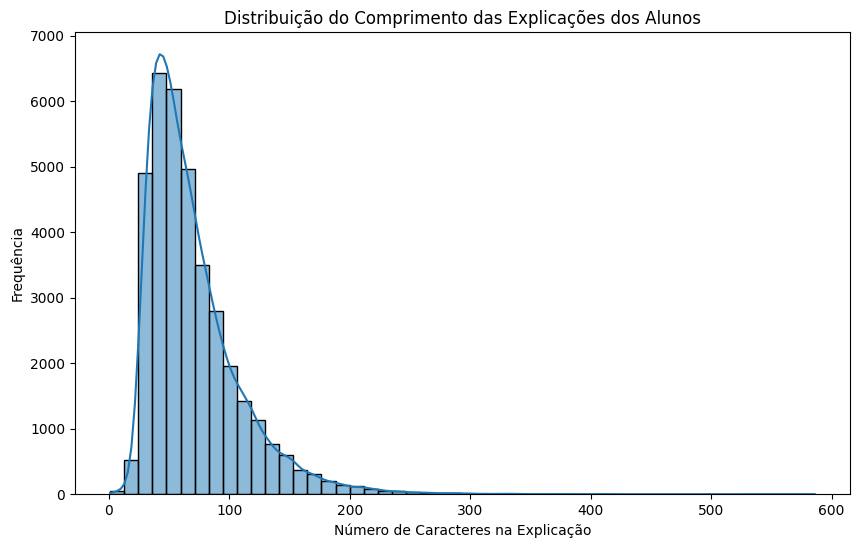

In [235]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['explanation_length'].dropna(), bins=50, kde=True)
plt.title('Distribuição do Comprimento das Explicações dos Alunos')
plt.xlabel('Número de Caracteres na Explicação')
plt.ylabel('Frequência')
plt.show()

In [236]:
#Inicialização do Lematizador
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""


    text = text.lower()


    text = re.sub(r'[^a-z\s]', '', text)


    text = re.sub(r'\s+', ' ', text).strip()


    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]


    tokens = [lemmatizer.lemmatize(word) for word in tokens]


    return " ".join(tokens)


train_df['processed_explanation'] = train_df['StudentExplanation'].apply(preprocess_text)


print("Exemplo de Explicação Original vs. Processada:")
print(f"Original: {train_df['StudentExplanation'][0]}")
print(f"Processado: {train_df['processed_explanation'][0]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Exemplo de Explicação Original vs. Processada:
Original: 0ne third is equal to tree nineth
Processado: ne third equal tree nineth


In [237]:
#Vetorizador
vectorizer_bow = CountVectorizer(max_features=5000)
X_bow = vectorizer_bow.fit_transform(train_df['processed_explanation'])

print("Dimensões do vetor Bag of Words:", X_bow.shape)

Dimensões do vetor Bag of Words: (36696, 4826)


In [238]:
#TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer_tfidf.fit_transform(train_df['processed_explanation'])

print("Dimensões do vetor TF-IDF:", X_tfidf.shape)

Dimensões do vetor TF-IDF: (36696, 4826)


In [239]:
#Modelagem
train_df['target'] = train_df['Category'] + ':' + train_df['Misconception']

print("Distribuição dos Alvos:")
print(train_df['target'].value_counts().head())

Distribuição dos Alvos:
target
False_Misconception:Incomplete     1446
False_Misconception:Additive        891
False_Misconception:Duplication     698
False_Misconception:Subtraction     618
False_Misconception:Positive        564
Name: count, dtype: int64


In [240]:
train_df['processed_explanation'] = train_df['processed_explanation'].astype(str)

train_df['processed_explanation'].fillna('', inplace=True)

train_df['Misconception'].fillna('Nenhum', inplace=True)

print("Verificação de valores nulos antes do `train_test_split`:")
print(train_df[['processed_explanation', 'target']].isna().sum())

Verificação de valores nulos antes do `train_test_split`:
processed_explanation        0
target                   26836
dtype: int64


/tmp/ipython-input-4248588927.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['processed_explanation'].fillna('', inplace=True)
/tmp/ipython-input-4248588927.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [241]:
#Modelagem
from sklearn.model_selection import train_test_split
train_df.dropna(subset=['target'], inplace=True)
class_counts = train_df['target'].value_counts()
single_member_classes = class_counts[class_counts == 1].index

train_df = train_df[~train_df['target'].isin(single_member_classes)]
X = train_df['processed_explanation']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de validação: {X_val.shape[0]} amostras")

Tamanho do conjunto de treino: 7884 amostras
Tamanho do conjunto de validação: 1971 amostras


In [242]:
vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

model = LogisticRegression(random_state=42)

model.fit(X_train_vec, y_train)

predictions = model.predict(X_val_vec)

print("Relatório de Classificação:")
print(classification_report(y_val, predictions))
print(f"Acurácia do modelo: {accuracy_score(y_val, predictions):.4f}")

Relatório de Classificação:
                                                            precision    recall  f1-score   support

                         False_Misconception:Adding_across       0.48      0.52      0.50        61
                          False_Misconception:Adding_terms       0.00      0.00      0.00        19
                              False_Misconception:Additive       0.50      0.75      0.60       178
                             False_Misconception:Base_rate       0.00      0.00      0.00         4
                             False_Misconception:Certainty       1.00      0.75      0.86         4
                            False_Misconception:Definition       0.91      1.00      0.95        10
               False_Misconception:Denominator-only_change       0.67      0.53      0.59        66
                              False_Misconception:Division       0.00      0.00      0.00        11
                           False_Misconception:Duplication       0.40  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [243]:
from sklearn.ensemble import RandomForestClassifier
class_counts = train_df['target'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
train_df = train_df[~train_df['target'].isin(single_member_classes)]

X = train_df['processed_explanation']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_val_vec)
print("Relatório de Classificação (RandomForest balanceados):")
print(classification_report(y_val, predictions))
print(f"Acurácia do modelo: {accuracy_score(y_val, predictions):.4f}")

Relatório de Classificação (RandomForest balanceados):
                                                            precision    recall  f1-score   support

                         False_Misconception:Adding_across       0.50      0.54      0.52        61
                          False_Misconception:Adding_terms       0.12      0.37      0.19        19
                              False_Misconception:Additive       0.60      0.69      0.64       178
                             False_Misconception:Base_rate       0.33      0.50      0.40         4
                             False_Misconception:Certainty       0.75      0.75      0.75         4
                            False_Misconception:Definition       0.82      0.90      0.86        10
               False_Misconception:Denominator-only_change       0.76      0.68      0.72        66
                              False_Misconception:Division       0.75      0.27      0.40        11
                           False_Misconcepti

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [244]:
test_df.rename(columns={'StudentExplanation': 'processed_explanation'}, inplace=True)
test_df['processed_explanation'].fillna('', inplace=True)

X_test_vec = vectorizer.transform(test_df['processed_explanation'])

test_predictions = model.predict(X_test_vec)

print("As primeiras 5 previsões para o conjunto de teste:")
print(test_predictions[:5])

As primeiras 5 previsões para o conjunto de teste:
['True_Misconception:WNB' 'False_Misconception:Incomplete'
 'False_Misconception:Ignores_zeroes']


/tmp/ipython-input-3566542542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['processed_explanation'].fillna('', inplace=True)


In [245]:
test_df['processed_explanation'] = test_df['processed_explanation'].fillna('')

test_df.rename(columns={'StudentExplanation': 'processed_explanation'}, inplace=True)

test_df['processed_explanation'] = test_df['processed_explanation'].fillna('')

X_test_vec = vectorizer.transform(test_df['processed_explanation'])
test_predictions = model.predict(X_test_vec)

submission_df = pd.DataFrame({
    'row_id': test_df['row_id'],
    'Category:Misconception': test_predictions
})

submission_df.to_csv('submission.csv', index=False)

print("Arquivo de submissão criado com sucesso!")

Arquivo de submissão criado com sucesso!


In [246]:
#Variável 'target'
target_counts = train_df['target'].value_counts()
print("Distribuição das classes na variável 'target':")
print(target_counts)

target_proportions = train_df['target'].value_counts(normalize=True) * 100
print("Distribuição percentual das classes:")
print(target_proportions)

print(f"Total de classes únicas: {train_df['target'].nunique()}")

Distribuição das classes na variável 'target':
target
False_Misconception:Incomplete                                1446
False_Misconception:Additive                                   891
False_Misconception:Duplication                                698
False_Misconception:Subtraction                                618
False_Misconception:Positive                                   564
False_Misconception:Wrong_term                                 550
False_Misconception:Wrong_fraction                             412
False_Misconception:Inversion                                  409
False_Misconception:Irrelevant                                 409
False_Misconception:Mult                                       345
False_Misconception:Denominator-only_change                    332
False_Misconception:Whole_numbers_larger                       328
False_Misconception:Adding_across                              306
False_Misconception:WNB                                        291
False_Mi

In [247]:
train_df['word_count'] = train_df['StudentExplanation'].apply(lambda x: len(str(x).split()))

print("Estatísticas da contagem de palavras na coluna 'StudentExplanation':")
print(train_df['word_count'].describe())

from collections import Counter

def extract_words(text):
    words = re.findall(r'\b\w+\b', str(text).lower())
    return words

all_words = []
train_df['StudentExplanation'].apply(lambda x: all_words.extend(extract_words(x)))

word_freq = Counter(all_words)

print("20 palavras mais comuns:")
print(word_freq.most_common(20))

Estatísticas da contagem de palavras na coluna 'StudentExplanation':
count    9855.000000
mean       14.867073
std         6.966342
min         1.000000
25%        10.000000
50%        13.000000
75%        18.000000
max        84.000000
Name: word_count, dtype: float64
20 palavras mais comuns:
[('3', 7101), ('is', 7012), ('the', 5812), ('because', 5328), ('and', 5248), ('i', 4246), ('5', 4109), ('you', 3866), ('it', 3576), ('9', 3238), ('so', 3064), ('2', 2815), ('to', 2666), ('are', 2553), ('15', 2428), ('1', 2155), ('think', 2075), ('by', 2049), ('a', 1990), ('this', 1957)]


In [248]:
#Tabela Cruzada
cross_tab = pd.crosstab(train_df['MC_Answer'], train_df['target'], normalize='index') * 100
print("Tabela cruzada entre MC_Answer e target:")
print(cross_tab)

Tabela cruzada entre MC_Answer e target:
target                                False_Misconception:Adding_across  \
MC_Answer                                                                 
Certain                                                        0.000000   
Impossible                                                     0.000000   
Not enough information                                         0.000000   
Unlikely                                                       0.000000   
\( -13 \)                                                      0.000000   
\( -3 \)                                                       0.000000   
\( 10 \)                                                       0.000000   
\( 13 \)                                                       0.000000   
\( 15 \)                                                       0.000000   
\( 192 \) hours                                                0.000000   
\( 20 \)                                                   

In [249]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print("Melhor F1-Score (macro) na validação cruzada:")
print(grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores parâmetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Melhor F1-Score (macro) na validação cruzada:
0.3399740143600964


In [250]:
best_model = grid_search.best_estimator_

predictions = best_model.predict(X_val_vec)

print("Relatório de Classificação (Modelo Otimizado):")
print(classification_report(y_val, predictions))
print(f"Acurácia do modelo: {accuracy_score(y_val, predictions):.4f}")

Relatório de Classificação (Modelo Otimizado):
                                                            precision    recall  f1-score   support

                         False_Misconception:Adding_across       0.49      0.54      0.52        61
                          False_Misconception:Adding_terms       0.16      0.37      0.22        19
                              False_Misconception:Additive       0.58      0.67      0.62       178
                             False_Misconception:Base_rate       0.33      0.50      0.40         4
                             False_Misconception:Certainty       0.75      0.75      0.75         4
                            False_Misconception:Definition       0.82      0.90      0.86        10
               False_Misconception:Denominator-only_change       0.77      0.71      0.74        66
                              False_Misconception:Division       0.75      0.27      0.40        11
                           False_Misconception:Dupli

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [251]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [252]:
train_df.rename(columns={'StudentExplanation': 'processed_explanation'}, inplace=True)
train_df['processed_explanation'] = train_df['processed_explanation'].fillna('')
train_df.dropna(subset=['target'], inplace=True)
class_counts = train_df['target'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
train_df = train_df[~train_df['target'].isin(single_member_classes)]

label_map = {label: i for i, label in enumerate(train_df['target'].unique())}
train_df['target_id'] = train_df['target'].map(label_map)

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

all_tokens = [token for text in train_df['processed_explanation'] for token in tokenize(text)]
vocab = {token: i for i, token in enumerate(sorted(list(set(all_tokens))))}
vocab['<unk>'] = len(vocab)

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor([vocab.get(token, vocab['<unk>']) for token in tokenize(text)], dtype=torch.long) for text in texts]
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

X_train, X_val, y_train, y_val = train_test_split(train_df['processed_explanation'], train_df['target_id'], test_size=0.2, random_state=42, stratify=train_df['target_id'])

train_dataset = TextDataset(X_train, y_train, vocab)
val_dataset = TextDataset(X_val, y_val, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [253]:
class SimpleClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super(SimpleClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        mean_embedding = embedded.mean(dim=1)
        output = self.fc1(mean_embedding)
        output = self.relu(output)
        output = self.fc2(output)
        return output

vocab_size = len(vocab)
embedding_dim = 100
num_classes = len(label_map)

model = SimpleClassifier(vocab_size, embedding_dim, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Modelo PyTorch pronto para treinamento!")

Modelo PyTorch pronto para treinamento!


In [254]:
train_df.rename(columns={'StudentExplanation': 'processed_explanation'}, inplace=True)
train_df['processed_explanation'] = train_df['processed_explanation'].fillna('')
train_df.dropna(subset=['target'], inplace=True)
class_counts = train_df['target'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
train_df = train_df[~train_df['target'].isin(single_member_classes)]

label_map = {label: i for i, label in enumerate(train_df['target'].unique())}
train_df['target_id'] = train_df['target'].map(label_map)


X_train, X_val, y_train, y_val = train_test_split(
    train_df[['processed_explanation']],
    train_df['target_id'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['target_id']
)


X_train_list = X_train.values.ravel().tolist()
X_val_list = X_val.values.ravel().tolist()
y_train_list = y_train.tolist()
y_val_list = y_val.tolist()


def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

all_tokens = [token for text in train_df['processed_explanation'] for token in tokenize(text)]
vocab = {token: i for i, token in enumerate(sorted(list(set(all_tokens))))}
vocab['<pad>'] = 0
vocab['<unk>'] = len(vocab)

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [tokenize(text) for text in texts]
        self.labels = labels
        self.vocab = vocab
        self.max_len = 50

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        token_ids = [self.vocab.get(token, self.vocab['<unk>']) for token in self.texts[idx]]
        padded_ids = token_ids[:self.max_len]
        padded_ids = padded_ids + [self.vocab['<pad>']] * (self.max_len - len(padded_ids))

        return torch.tensor(padded_ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = TextDataset(X_train_list, y_train_list, vocab)
val_dataset = TextDataset(X_val_list, y_val_list, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


class SimpleClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super(SimpleClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.fc1 = nn.Linear(embedding_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        mean_embedding = embedded.mean(dim=1)
        output = self.fc1(mean_embedding)
        output = self.relu(output)
        output = self.fc2(output)
        return output

vocab_size = len(vocab)
embedding_dim = 100
num_classes = len(label_map)
model = SimpleClassifier(vocab_size, embedding_dim, num_classes)


class_counts_tensor = torch.tensor(train_df['target_id'].value_counts().sort_index().values, dtype=torch.float)
total_samples = class_counts_tensor.sum()
class_weights = total_samples / class_counts_tensor
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    for texts, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for texts, labels in val_loader:
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f'Resultados após a Época {epoch+1}')
    print("Relatório de Classificação na Validação:")
    print(classification_report(all_labels, all_preds, zero_division=0))
    print(f"Acurácia de Validação: {accuracy_score(all_labels, all_preds):.4f}")

Resultados após a Época 1
Relatório de Classificação na Validação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00       289
           4       0.00      0.00      0.00        39
           5       0.00      0.00      0.00        69
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00        82
          11       0.00      0.00      0.00        54
          12       0.00      0.00      0.00       178
          13       0.00      0.00      0.00        18
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00        19
          16  

In [255]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, n_layers, dropout):
        super(LSTMClassifier, self).__init__()


        self.embedding = nn.Embedding(vocab_size, embedding_dim)


        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            dropout=dropout,
                            batch_first=True)


        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        embedded = self.embedding(x)


        lstm_out, (hidden, cell) = self.lstm(embedded)


        last_hidden = hidden[-1]

        output = self.fc(last_hidden)

        return output


hidden_dim = 256
n_layers = 2
dropout = 0.5
vocab_size = len(vocab)
embedding_dim = 100
num_classes = len(label_map)


model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, num_classes, n_layers, dropout)


class_counts_tensor = torch.tensor(train_df['target_id'].value_counts().sort_index().values, dtype=torch.float)
total_samples = class_counts_tensor.sum()
class_weights = total_samples / class_counts_tensor
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10


for epoch in range(num_epochs):
    model.train()
    for texts, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for texts, labels in val_loader:
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f'Resultados após a Época {epoch+1}')
    print("Relatório de Classificação na Validação:")
    print(classification_report(all_labels, all_preds, zero_division=0))
    print(f"Acurácia de Validação: {accuracy_score(all_labels, all_preds):.4f}")

Resultados após a Época 1
Relatório de Classificação na Validação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00       289
           4       0.00      0.00      0.00        39
           5       0.00      0.00      0.00        69
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00        82
          11       0.00      0.00      0.00        54
          12       0.09      1.00      0.17       178
          13       0.00      0.00      0.00        18
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00        19
          16  

In [256]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, n_layers, dropout):
        super(LSTMClassifier, self).__init__()


        self.embedding = nn.Embedding(vocab_size, embedding_dim)


        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            dropout=dropout,
                            batch_first=True)


        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        #x tem a forma: (batch_size, seq_len)
        embedded = self.embedding(x)


        lstm_out, (hidden, cell) = self.lstm(embedded)


        last_hidden = hidden[-1]

        output = self.fc(last_hidden)

        return output


hidden_dim = 256
n_layers = 2
dropout = 0.5
vocab_size = len(vocab)
embedding_dim = 100
num_classes = len(label_map)


model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, num_classes, n_layers, dropout)


class_counts_tensor = torch.tensor(train_df['target_id'].value_counts().sort_index().values, dtype=torch.float)
total_samples = class_counts_tensor.sum()
class_weights = total_samples / class_counts_tensor
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10


for epoch in range(num_epochs):
    model.train()
    for texts, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for texts, labels in val_loader:
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f'Resultados após a Época {epoch+1}')
    print("Relatório de Classificação na Validação:")
    print(classification_report(all_labels, all_preds, zero_division=0))
    print(f"Acurácia de Validação: {accuracy_score(all_labels, all_preds):.4f}")

Resultados após a Época 1
Relatório de Classificação na Validação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00       289
           4       0.00      0.00      0.00        39
           5       0.00      0.00      0.00        69
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00        82
          11       0.00      0.00      0.00        54
          12       0.00      0.00      0.00       178
          13       0.00      0.00      0.00        18
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00        19
          16  

# Conclusão

Apesar de algumas limitações técnicas encontradas, a abordagem de usar modelos como o LSTM ou o RandomForest para classificar textos é perfeitamente válida e promissora para este tipo de problema educacional. Uma vez superado o problema de formatação dos dados, o modelo poderia ser treinado e avaliado, fornecendo um valioso recurso para identificar e corrigir mal-entendidos dos alunos em larga escala.

# **Nathália Sorg**